In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from pyproj import Transformer

In [386]:
# Set up transformer from OSGB36 / British National Grid to WGS84 lat/lon
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

# Map OS two-letter codes to their 100 km square origins
# Source: Ordnance Survey National Grid
OS_SQUARES = {
    "SV": (0, 0), "SW": (100000, 0), "SX": (200000, 0), "SY": (300000, 0), "SZ": (400000, 0), "TV": (500000, 0),
    "SQ": (0, 100000), "SR": (100000, 100000), "SS": (200000, 100000), "ST": (300000, 100000), "SU": (400000, 100000), "TQ": (500000, 100000), "TR": (600000, 100000),
    "SL": (0, 200000), "SM": (100000, 200000), "SN": (200000, 200000), "SO": (300000, 200000), "SP": (400000, 200000), "TL": (500000, 200000), "TM": (600000, 200000),
    "SF": (0, 300000), "SG": (100000, 300000), "SH": (200000, 300000), "SJ": (300000, 300000), "SK": (400000, 300000), "TF": (500000, 300000), "TG": (600000, 300000),
    "SA": (0, 400000), "SB": (100000, 400000), "SC": (200000, 400000), "SD": (300000, 400000), "SE": (400000, 400000), "TA": (500000, 400000), "TB": (600000, 400000),
    "NV": (0, 500000), "NW": (100000, 500000), "NX": (200000, 500000), "NY": (300000, 500000), "NZ": (400000, 500000), "OV": (500000, 500000),
    "NQ": (0, 600000), "NR": (100000, 600000), "NS": (200000, 600000), "NT": (300000, 600000), "NU": (400000, 600000), "OQ": (500000, 600000), "OR": (600000, 600000),
    "NL": (0, 700000), "NM": (100000, 700000), "NN": (200000, 700000), "NO": (300000, 700000), "NP": (400000, 700000), "OL": (500000, 700000), "OM": (600000, 700000),
    "NF": (0, 800000), "NG": (100000, 800000), "NH": (200000, 800000), "NJ": (300000, 800000), "NK": (400000, 800000), "OF": (500000, 800000), "OG": (600000, 800000),
    "NA": (0, 900000), "NB": (100000, 900000), "NC": (200000, 900000), "ND": (300000, 900000), "NE": (400000, 900000), "OA": (500000, 900000), "OB": (600000, 900000),
    "HV": (0, 1000000), "HW": (100000, 1000000), "HX": (200000, 1000000), "HY": (300000, 1000000), "HZ": (400000, 1000000), "JV": (500000, 1000000)
}

def osgrid_to_lonlat(os_ref: str):
    os_ref = os_ref.strip().upper()
    letters = os_ref[:2]
    digits = os_ref[2:]
    
    if letters not in OS_SQUARES:
        raise ValueError(f"Unknown grid letters: {letters}")
    
    # Half-split digits for easting/northing
    n = len(digits) // 2
    easting_digits = digits[:n]
    northing_digits = digits[n:]
    
    # Scale factor (e.g., 3 digits → 100 m precision)
    scale = 10 ** (5 - n)
    
    easting = OS_SQUARES[letters][0] + int(easting_digits) * scale
    northing = OS_SQUARES[letters][1] + int(northing_digits) * scale
    
    lon, lat = transformer.transform(easting, northing)
    return lat, lon

# Extract lat/lon from OS grid references
def add_lat_lon(df):
    lats = []
    lons = []
    for loc in df['Project Location']:
        try:
            lat, lon = osgrid_to_lonlat(loc)
            lats.append(lat)
            lons.append(lon)
        except (ValueError, TypeError):
            lats.append(None)
            lons.append(None)

    df['Latitude'] = lats
    df['Longitude'] = lons

    return df


In [10]:
df = pd.read_csv(
    Path.cwd().parent / 'data' /
    'UK_energy_build__2025_2030__with_coordinates.csv'
)
df.head()

,Year,Department,Asset_Name,Asset_Type,Capacity_MW,Latitude,Longitude,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Location_Type,Notes,Sources
0,2025,Offshore wind,Moray West,Offshore wind farm,882,58.094000,-2.988000,NaN,NaN,NaN,NaN,point,Coordinates from Wikipedia (Moray West Wind Fa...,https://en.wikipedia.org/wiki/Moray_West_Wind_...
1,2025,Offshore wind,Neart na Gaoithe (NnG),Offshore wind farm,448,56.270000,-2.250000,NaN,NaN,NaN,NaN,point,Coordinates from Global Energy Monitor (GEM).,https://www.gem.wiki/Neart_Na_Gaoithe_wind_farm
2,2025,Offshore wind,Dogger Bank B (Creyke Beck B),Offshore wind farm,1200,54.979972,1.679972,NaN,NaN,NaN,NaN,point,Coordinates from TheWindPower.net page for Dog...,https://www.thewindpower.net/windfarm_en_16773...
3,2026,Offshore wind,Dogger Bank C (Teesside A),Offshore wind farm,1200,55.039972,2.819972,NaN,NaN,NaN,NaN,point,Coordinates from TheWindPower.net page for Dog...,https://www.thewindpower.net/windfarm_en_16689...
4,2026,Offshore wind,Sofia (Dogger Bank Teesside B),Offshore wind farm,1400,55.210000,2.330000,NaN,NaN,NaN,NaN,point,Coordinates from Global Energy Monitor (Sofia ...,https://www.gem.wiki/Sofia_wind_farm


In [19]:
fleet = pd.read_csv(
    Path.cwd().parent / 'data' /
    'gb_2024_capacities.csv', index_col=0
)
fleet.head()

,Installed_Capacity_GW,Notes,Source_URL
Technology,,,
Onshore wind,15.3,GB onshore wind capacity end-2024 (Electric In...,https://reports.electricinsights.co.uk/wp-cont...
Offshore wind,14.8,GB offshore wind capacity end-2024 (Electric I...,https://reports.electricinsights.co.uk/wp-cont...
Solar PV,17.2,GB solar PV capacity end-2024 (Electric Insights),https://reports.electricinsights.co.uk/wp-cont...
Battery storage (BESS),4.7,Total battery capacity in GB (end 2024),https://modoenergy.com/research/gb-battery-ene...
Pumped-storage hydro (PSH),2.8,Operational pumped hydro capacity in GB (4 sch...,https://www.drax.com/wp-content/uploads/2024/0...


In [337]:
# csv version of
# https://assets.publishing.service.gov.uk/media/65b1463d160765000d18f834/contracts-for-difference-cfd-allocation-round-4-results.pdf
ar4 = pd.read_csv(Path.cwd().parent / 'data' / 'ar4_results.csv', index_col=0)
# csv version of
# https://assets.publishing.service.gov.uk/media/64fa0473fdc5d10014fce820/cfd-ar5-results.pdf
ar5 = pd.read_csv(Path.cwd().parent / 'data' / 'ar5_results.csv', index_col=0)
# csv version of
# https://assets.publishing.service.gov.uk/media/66d6ad7c6eb664e57141db4b/Contracts_for_Difference_Allocation_Round_6_results.pdf
ar6 = pd.read_csv(Path.cwd().parent / 'data' / 'ar6_results.csv', index_col=0)

ar4 = ar4.rename(columns={'Strike Price(£/MWh)': 'Strike Price (£/MWh)', 'Size(MW)': 'Size (MW)'})
ar5 = ar5.rename(columns={'ProjectLocation': 'Project Location'})

ar5 = add_lat_lon(ar5)
ar6 = add_lat_lon(ar6)

future_wind_generators = pd.concat((ar4, ar5, ar6))

pypsa_carrier_mapper = {
    'Onshore Wind (>5MW)': 'onwind',
    'Offshore Wind': 'offwind',
    'Floating Offshore Wind': 'offwind',
    'Remote Island Wind (RIW)': 'offwind',
}

future_wind_generators['pypsa_carrier'] = future_wind_generators['Technology Type'].map(pypsa_carrier_mapper)

future_wind_generators['optimistic_delivery_year'] = future_wind_generators['Delivery Year'].str.split('/').str[0].astype(int)
future_wind_generators['pessimistic_delivery_year'] = future_wind_generators['Delivery Year'].str.split('/').str[1].astype(int) + 2000

future_wind_generators.loc['Viking Wind Farm AR5', ['Longitude', 'Latitude']] = (-1.394, 60.264)

In [339]:
cfds = pd.read_csv(
    Path.cwd().parent / 'data' / 'prerun' / 'cfd_strike_prices.csv', index_col=0
)

for unit in new_wind.index:
    cfds.loc[unit, :] = new_wind.loc[unit, 'Strike Price (£/MWh)']

cfds.shape

(103, 15)

In [387]:
import pypsa
import geopandas as gpd
import warnings
# warnings.filterwarning('ignore')

future = '2028'

n = pypsa.Network(
    Path.cwd().parent / 'results' / '2024-03-22' / 'network_flex_s_national_solved.nc'
)

base_n = pypsa.Network(
    Path.cwd().parent / 'results' / '2024-03-22' / 'network_flex_s.nc'
)


c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatibl

In [388]:
future_onshore_line_upgrades = pd.read_csv(
    Path.cwd().parent / 'data' / 'GB_onshore_transmission_additions_2025_2030.csv',
    index_col=0
)

In [ ]:

def adjust_to_future_year(
    n,
    year,
    current_fleet,
    future_wind_generators,
    future_assets,
    future_onshore_line_upgrades,
    base,
    ):

    n = n.copy()

    if year == 'off':
        return

    year = int(year)

    assert n.snapshots[0].year == 2024, 'model year has to be 2024 for future simulation'

    print('Warning! Check for changes in fossil, nuclear and biomass fleet')
    print('Warning! Not yet increased demand')

    buslocs = n.buses.loc[n.buses.country == 'GB', ['x', 'y']]

    ##### Onshore transmission lines #####

    for line, row in future_onshore_line_upgrades.iterrows():

        pt_start = row[['lon_start', 'lat_start']].values
        # Calculate distances from point to all bus locations
        distances = np.sqrt(
            (buslocs['x'] - pt_start[0])**2 + 
            (buslocs['y'] - pt_start[1])**2
        )
        bus0 = distances.idxmin()
        
        pt_end = row[['lon_end', 'lat_end']].values
        distances = np.sqrt(
            (buslocs['x'] - pt_end[0])**2 + 
            (buslocs['y'] - pt_end[1])**2
        )
        bus1 = distances.idxmin()

        if bus0 == bus1:
            continue

        local_lines = base.links.index[
            (base.links.bus0 == bus0) |
            (base.links.bus1 == bus1) |
            (base.links.bus0 == bus1) |
            (base.links.bus1 == bus0)
            ]

        nameplate_capacity = base.links.loc[local_lines, 'p_nom'].mean()
        calibrated_capacity = n.links.loc[local_lines, 'p_nom'].mean()

        calibration_factor = calibrated_capacity / nameplate_capacity
        
        cols = n.links_t.p_max_pu.columns
        p_max_pu = n.links_t.p_max_pu.loc[:, cols.intersection(local_lines)]
        p_min_pu = n.links_t.p_min_pu.loc[:, cols.intersection(local_lines)]

        if p_max_pu.empty:
            p_max_pu = 1
            p_min_pu = -1
        else:        
            p_max_pu = p_max_pu.mean(axis=1)
            p_min_pu = p_min_pu.mean(axis=1)

        n.add(
            'Link',
            line,
            bus0=bus0,
            bus1=bus1,
            p_nom=row['p_nom'] * calibration_factor,
            p_max_pu=p_max_pu,
            p_min_pu=p_min_pu,
            carrier='AC',
        )

    # Assets are treated differently; iterating over one-by-one assets first

    # ignored Offshore Permitted Reduction because the model works with physical notifications
    # ignored tidal, geothermal
    
    ##### Wind #####

    current_capacities = {
        'onwind': fleet.loc['Onshore wind', 'Installed_Capacity_GW'] * 1000,
        'offwind': fleet.loc['Offshore wind', 'Installed_Capacity_GW'] * 1000,
    }

    network_capacities = {
        pypsa_carrier: pd.concat((
            n.generators.loc[gen, 'p_nom'] * (
                n.generators_t.p_max_pu[gen] 
            if gen in n.generators_t.p_max_pu.columns 
        else pd.Series(1, index=n.generators_t.p_max_pu.index)
            )
            for gen in n.generators.index[n.generators.carrier == pypsa_carrier]
        ), axis=1).sum(axis=1)
        for pypsa_carrier in ['onwind', 'offwind']
    }

    for name, row in future_wind_generators.iterrows():

        print(f'Adding {name}')

        if year < row['pessimistic_delivery_year']:
            continue

        # taking fleet strength not from model but dataset because the model only knows
        # weather-dependent actual generation capacity during that day
        current_capacity = current_capacities[row['pypsa_carrier']]
        network_capacity = network_capacities[row['pypsa_carrier']]

        pt = row[['Longitude', 'Latitude']].values

        # Calculate distances from point to all bus locations
        distances = np.sqrt(
            (buslocs['x'] - pt[0])**2 + 
            (buslocs['y'] - pt[1])**2
        )
        
        # Get index of minimum distance
        closest_bus = distances.idxmin()

        new_capacity_share = row['Size (MW)'] / current_capacity
        new_capacity = network_capacity * new_capacity_share

        p_nom = new_capacity.max()
        p_max_pu = new_capacity / p_nom

        n.add(
            'Generator',
            name,
            bus=closest_bus,
            carrier=row['pypsa_carrier'],
            p_nom=p_nom,
            p_max_pu=p_max_pu,
            marginal_cost=0,
        )
    
    ##### Batteries

    installed_capacity = fleet.loc['Battery storage (BESS)', 'Installed_Capacity_GW']

    new_assets = future_assets.loc[
        (future_assets.Year <= year) &
        (future_assets.Department == 'Battery storage'),
        'Capacity_MW'
    ].sum() / 1000

    print(f'Adjusting Battery Capacity from 2024 ({installed_capacity} GW) by adding {new_assets} GW')

    factor = (new_assets + installed_capacity) / installed_capacity
    n.storage_units.loc[n.storage_units.carrier == 'battery', 'p_nom'] *= factor

    ##### Offshore transmission lines (all of which are HVDC)

    # line capacities are scaled such that the model achieves realistic constraint management
    # therefore adding the new line at nameplate capacity will overestimate capacity
    # we therefore scale the nameplate capacity by considering the Western HVDC Link (in the model '8009')
    # the factor is its power capacity in the model divided by its nameplate capacity (2,250 MW)

    if '8009' in n.links.index:

        scaling_factor = n.links.loc['8009', 'p_nom'] / 2250

        new_assets = future_assets.loc[
            (future_assets.Year <= year) &
            (future_assets.Department == 'Transmission')
        ]

        for _, row in new_assets.iterrows():

            print('Adding Transmission Line: ', row.Asset_Name)

            kwargs = {
                'p_nom': row['Capacity_MW'] * scaling_factor,
                'type': 'HVDC underwater cable',
                'carrier': 'DC',
            }

            if '8009' in n.links_t.p_max_pu.columns:
                kwargs['p_max_pu'] = n.links_t.p_max_pu['8009']
                kwargs['p_min_pu'] = n.links_t.p_min_pu['8009']
            
            pt_start = row[['Start_Longitude', 'Start_Latitude']].values
            # Calculate distances from point to all bus locations
            distances = np.sqrt(
                (buslocs['x'] - pt_start[0])**2 + 
                (buslocs['y'] - pt_start[1])**2
            )
            bus0 = distances.idxmin()

            if bus0 == bus1:
                continue
            
            pt_end = row[['End_Longitude', 'End_Latitude']].values
            distances = np.sqrt(
                (buslocs['x'] - pt_end[0])**2 + 
                (buslocs['y'] - pt_end[1])**2
            )
            bus1 = distances.idxmin()

            n.add(
                'Link',
                row.Asset_Name,
                bus0=bus0,
                bus1=bus1,
                **kwargs
            )

    return n


In [392]:
future_n = adjust_to_future_year(
    n,
    2030,
    fleet,
    future_wind_generators,
    df,
    future_onshore_line_upgrades,
    base_n,
)

c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatibl

Warning! Check for changes in fossil, nuclear and biomass fleet
Warning! Not yet increased demand
GB GB
GB GB
GB GB
GB GB
Adding Cumberhead West
Adding Arecleoch Wind Farm Extension
Adding Kilgallioch windfarm extension
Adding Stranoch Wind Farm
Adding North Kyle Energy Project
Adding Hagshaw Hill Repowering
Adding Broken Cross Wind Farm
Adding Douglas West Extension
Adding High Constellation Wind Farm
Adding Chirmorie Wind Farm
Adding TwinHub Floating Offshore Wind Project
Adding Stornoway Wind Farm
Adding Orkney Community Wind Farm Project - Hoy
Adding Orkney Community Wind Farm Project - Quanterness
Adding Mossy Hill
Adding Beaw Field
Adding Viking Wind Farm
Adding Inch Cape Phase 1
Adding EA3 Phase 1
Adding Norfolk Boreas (Phase 1)
Adding Hornsea Project Three Offshore Wind Farm
Adding Moray West Offshore Wind Farm
Adding Strathy South WindFarm
Adding Clash Gour Wind Farm
Adding Limekiln Wind Farm
Adding Bhlaraidh Extension Wind Farm
Adding Enoch Hill Windfarm
Adding Blarghour Wind

In [393]:
future_n.generators

,bus,control,p_nom,carrier,marginal_cost,p_nom_opt,type,p_nom_extendable,p_nom_min,p_nom_max,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Generator,,,,,,,,,,,,,,,,,,,,,
CMSTW-1,GB,Slack,47.000000,onwind,-112.919554,47.0,,False,0.0,inf,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
ROTHW-1,GB,PQ,50.000000,onwind,-112.920474,50.0,,False,0.0,inf,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
PAUHW-1,GB,PQ,64.000000,onwind,-108.850575,64.0,,False,0.0,inf,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
CAIRW-2,GB,PQ,42.000000,onwind,-83.187731,42.0,,False,0.0,inf,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
MDHLW-1,GB,PQ,75.000000,onwind,-88.000000,75.0,,False,0.0,inf,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cloiche Wind Farm,GB,PQ,52.362485,onwind,0.000000,0.0,,False,0.0,inf,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
WINDY STANDARD III LIMITED,GB,PQ,35.149071,onwind,0.000000,0.0,,False,0.0,inf,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Green Volt Offshore Windfarm (GV01),GB,PQ,295.482432,offwind,0.000000,0.0,,False,0.0,inf,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [385]:
future_n.links_t['p_min_pu'].iloc[:,-5:]

Link,6146,Hinkley Point (Shurton) – Seabank 400 kV double-circuit (Hinkley Connection Project),Bramford – Twinstead Tee 400 kV reinforcement (new double-circuit & partial undergrounding),Overton (York North) – Monk Fryston reinforcement (Yorkshire GREEN 275/400 kV works),Kintore – Tealing (Emmock) via Hurlie 400 kV double-circuit (SSEN East Coast 400 kV)
snapshot,,,,,
2024-03-22 00:00:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216
2024-03-22 00:30:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216
2024-03-22 01:00:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216
2024-03-22 01:30:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216
2024-03-22 02:00:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216
2024-03-22 02:30:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216
2024-03-22 03:00:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216
2024-03-22 03:30:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216
2024-03-22 04:00:00,-0.472034,-0.618337,-0.618337,-0.618337,-0.526216


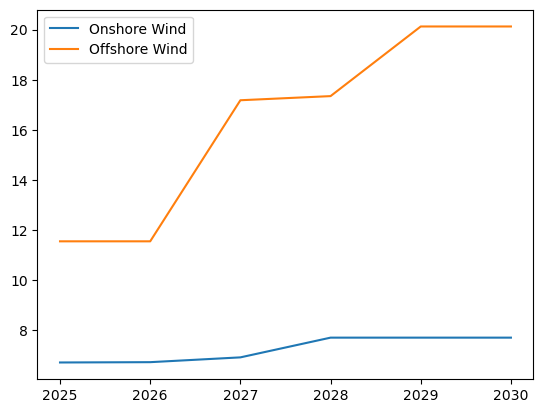

In [345]:
fig, ax = plt.subplots()
ax.plot(years, onwind_caps, label='Onshore Wind')
ax.plot(years, offwind_caps, label='Offshore Wind')
ax.legend()
plt.show()

In [142]:
base = pypsa.Network(
    Path.cwd().parent / 'data' / 'base.nc'
)

n.links.loc['8009', 'p_nom']

c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatibl

1925.0

In [ ]:
onshore = gpd.read_file(Path.cwd().parent / 'data' / 'regions_onshore_s.geojson')
offshore = gpd.read_file(Path.cwd().parent / 'data' / 'regions_offshore_s.geojson')

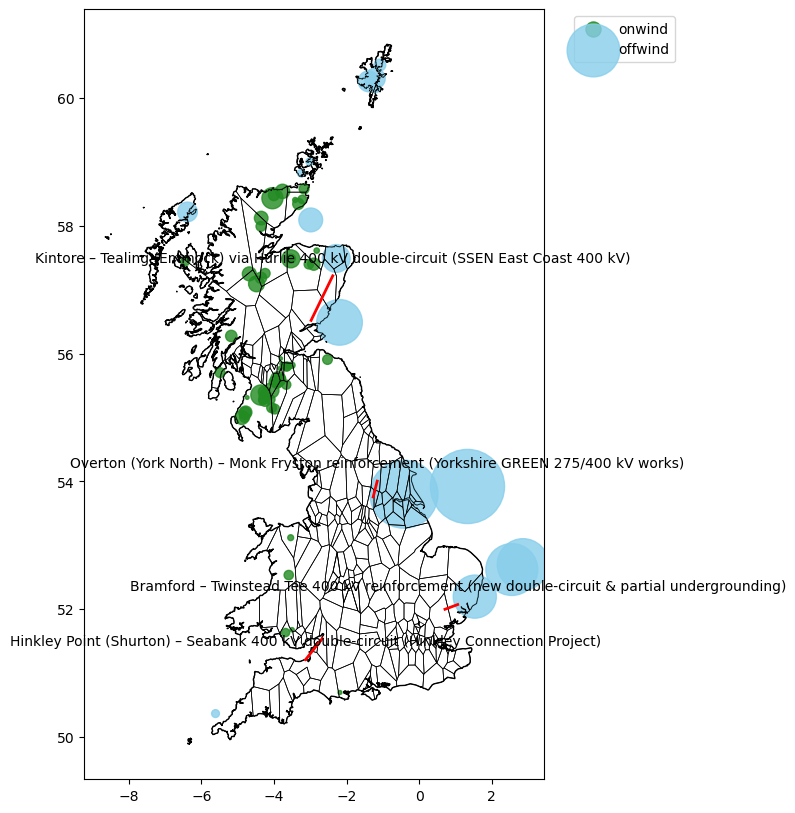

In [354]:
fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoSeries(onshore.unary_union).plot(ax=ax, facecolor='none', edgecolor='black')

# Define colors for each technology type
colors = {
    'onwind': 'forestgreen', 
    'offwind': 'skyblue'
}

# Create scatter plot for each technology type
for tech, color in colors.items():
    mask = future_wind_generators['pypsa_carrier'] == tech
    ax.scatter(
        future_wind_generators.loc[mask, 'Longitude'], 
        future_wind_generators.loc[mask, 'Latitude'],
        c=color,
        s=future_wind_generators.loc[mask, 'Size (MW)'],
        label=tech,
        alpha=0.8
    )

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

onshore.plot(ax=ax, facecolor='none', edgecolor='black', lw=0.5)

for line in onshore_line_upgrades.index:

    ax.plot(
        onshore_line_upgrades.loc[line, ['lon_start', 'lon_end']],
        onshore_line_upgrades.loc[line, ['lat_start', 'lat_end']],
        color='red',
        linewidth=2
    )
    ax.annotate(
        line,
        (onshore_line_upgrades.loc[line, 'lon_start'], onshore_line_upgrades.loc[line, 'lat_start']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
    )

plt.show()

In [349]:
onshore_line_upgrades.head()

,lon_start,lat_start,lon_end,lat_end,p_nom,first_operational_year,source
name,,,,,,,
Hinkley Point (Shurton) – Seabank 400 kV double-circuit (Hinkley Connection Project),-3.130424,51.208559,-2.670000,51.539200,4000,2025,https://www.nationalgrid.com/electricity-trans...
Bramford – Twinstead Tee 400 kV reinforcement (new double-circuit & partial undergrounding),1.060920,52.071240,0.710512,51.997128,4000,2029,https://www.nationalgrid.com/the-great-grid-up...
Overton (York North) – Monk Fryston reinforcement (Yorkshire GREEN 275/400 kV works),-1.156076,54.003644,-1.267110,53.755840,2000,2028,https://www.nationalgrid.com/the-great-grid-up...
Kintore – Tealing (Emmock) via Hurlie 400 kV double-circuit (SSEN East Coast 400 kV),-2.381450,57.218750,-2.977900,56.521280,4000,2030,https://www.ssen-transmission.co.uk/projects/p...
